In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
data=pd.read_excel('/content/drive/MyDrive/MY DATA.xlsx')

In [24]:
data.head()

,CCC No,Sex,Weight,Height,Age at Reporting,Differentiated Care Model,AHD Client,Risk Categorization,Current Regimen Line,Months Of Prescription,TB screening at last visit,Marital status,Employmet,Family Members,Alcoho and Drug Abuse
0,1.161400e+09,M,75.0,152.0,64,Fast Track-Facility ART distribution group,No,Unknown Risk,Second line,6,No TB signs,yes,no,yes,yes
1,1.161400e+09,F,73.0,165.0,58,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,9,No TB signs,yes,no,yes,no
2,1.161400e+09,F,42.0,156.0,54,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes
3,1.161400e+09,F,85.0,168.0,57,Fast Track,No,Unknown Risk,First line,7,No TB signs,yes,yes,yes,no
4,1.161400e+09,F,65.0,160.0,53,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CCC No                      1563 non-null   float64
 1   Sex                         1563 non-null   object 
 2   Weight                      1562 non-null   float64
 3   Height                      1562 non-null   float64
 4   Age at Reporting            1563 non-null   int64  
 5   Differentiated Care Model   1563 non-null   object 
 6   AHD Client                  1563 non-null   object 
 7   Risk Categorization         1563 non-null   object 
 8   Current Regimen Line        1563 non-null   object 
 9   Months Of Prescription      1563 non-null   int64  
 10  TB screening at last visit  1563 non-null   object 
 11  Marital status              1148 non-null   object 
 12  Employmet                   1148 non-null   object 
 13  Family Members              1148 

In [26]:
data.isnull().sum()

,0
CCC No,0
Sex,0
Weight,1
Height,1
Age at Reporting,0
Differentiated Care Model,0
AHD Client,0
Risk Categorization,0
Current Regimen Line,0
Months Of Prescription,0


In [27]:
data.drop(columns=['CCC No'], inplace=True, errors='ignore')

In [28]:
data.head()

,Sex,Weight,Height,Age at Reporting,Differentiated Care Model,AHD Client,Risk Categorization,Current Regimen Line,Months Of Prescription,TB screening at last visit,Marital status,Employmet,Family Members,Alcoho and Drug Abuse
0,M,75.0,152.0,64,Fast Track-Facility ART distribution group,No,Unknown Risk,Second line,6,No TB signs,yes,no,yes,yes
1,F,73.0,165.0,58,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,9,No TB signs,yes,no,yes,no
2,F,42.0,156.0,54,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes
3,F,85.0,168.0,57,Fast Track,No,Unknown Risk,First line,7,No TB signs,yes,yes,yes,no
4,F,65.0,160.0,53,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sex                         1563 non-null   object 
 1   Weight                      1562 non-null   float64
 2   Height                      1562 non-null   float64
 3   Age at Reporting            1563 non-null   int64  
 4   Differentiated Care Model   1563 non-null   object 
 5   AHD Client                  1563 non-null   object 
 6   Risk Categorization         1563 non-null   object 
 7   Current Regimen Line        1563 non-null   object 
 8   Months Of Prescription      1563 non-null   int64  
 9   TB screening at last visit  1563 non-null   object 
 10  Marital status              1148 non-null   object 
 11  Employmet                   1148 non-null   object 
 12  Family Members              1148 non-null   object 
 13  Alcoho and Drug Abuse       1148 

In [30]:
data.rename(columns={'Alcoho and Drug Abuse': 'Alcoho and Drug Use'}, inplace=True)
display(data.head())

,Sex,Weight,Height,Age at Reporting,Differentiated Care Model,AHD Client,Risk Categorization,Current Regimen Line,Months Of Prescription,TB screening at last visit,Marital status,Employmet,Family Members,Alcoho and Drug Use
0,M,75.0,152.0,64,Fast Track-Facility ART distribution group,No,Unknown Risk,Second line,6,No TB signs,yes,no,yes,yes
1,F,73.0,165.0,58,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,9,No TB signs,yes,no,yes,no
2,F,42.0,156.0,54,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes
3,F,85.0,168.0,57,Fast Track,No,Unknown Risk,First line,7,No TB signs,yes,yes,yes,no
4,F,65.0,160.0,53,Fast Track-Facility ART distribution group,No,Unknown Risk,First line,6,No TB signs,no,no,no,yes


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sex                         1563 non-null   object 
 1   Weight                      1562 non-null   float64
 2   Height                      1562 non-null   float64
 3   Age at Reporting            1563 non-null   int64  
 4   Differentiated Care Model   1563 non-null   object 
 5   AHD Client                  1563 non-null   object 
 6   Risk Categorization         1563 non-null   object 
 7   Current Regimen Line        1563 non-null   object 
 8   Months Of Prescription      1563 non-null   int64  
 9   TB screening at last visit  1563 non-null   object 
 10  Marital status              1148 non-null   object 
 11  Employmet                   1148 non-null   object 
 12  Family Members              1148 non-null   object 
 13  Alcoho and Drug Use         1148 

In [32]:
from sklearn.preprocessing import LabelEncoder as le

In [33]:
data = data[~data["Risk Categorization"].str.contains("Unknown Risk", na=False)]

In [34]:
data.head()

,Sex,Weight,Height,Age at Reporting,Differentiated Care Model,AHD Client,Risk Categorization,Current Regimen Line,Months Of Prescription,TB screening at last visit,Marital status,Employmet,Family Members,Alcoho and Drug Use
8,M,70.0,177.0,60,Fast Track-Facility ART distribution group,No,Medium Risk,First line,5,No TB signs,no,no,no,yes
10,F,71.0,160.0,56,Fast Track-Facility ART distribution group,Yes,Low Risk,First line,2,No TB signs,yes,yes,yes,no
11,F,66.0,166.0,46,Fast Track-Facility ART distribution group,No,Low Risk,First line,3,No TB signs,no,no,no,yes
14,F,34.0,154.0,27,Fast Track-Facility ART distribution group,No,Low Risk,First line,5,No TB signs,no,yes,no,no
22,F,57.0,158.0,54,Community ART Distribution - HCW Led,No,Low Risk,First line,5,No TB signs,yes,yes,yes,no


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 411 entries, 8 to 1538
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sex                         411 non-null    object 
 1   Weight                      411 non-null    float64
 2   Height                      411 non-null    float64
 3   Age at Reporting            411 non-null    int64  
 4   Differentiated Care Model   411 non-null    object 
 5   AHD Client                  411 non-null    object 
 6   Risk Categorization         411 non-null    object 
 7   Current Regimen Line        411 non-null    object 
 8   Months Of Prescription      411 non-null    int64  
 9   TB screening at last visit  411 non-null    object 
 10  Marital status              291 non-null    object 
 11  Employmet                   291 non-null    object 
 12  Family Members              291 non-null    object 
 13  Alcoho and Drug Use         291 non-nul

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
# Initialize the LabelEncoder
le = LabelEncoder()

# Encode the categorical column
data['Differentiated Care Model_Encoded'] = le.fit_transform(data['Differentiated Care Model'])
data['AHD Client_Encoded'] = le.fit_transform(data['AHD Client'])
data['Risk Categorization_Encoded'] = le.fit_transform(data['Risk Categorization'])
data['Current Regimen Line_Encoded'] = le.fit_transform(data['Current Regimen Line'])
data['TB screening at last visit_Encoded'] = le.fit_transform(data['TB screening at last visit'])
data['Marital status_Encoded'] = le.fit_transform(data['Marital status'])
data['Employmet_Encoded'] = le.fit_transform(data['Employmet'])
data['Family Members_Encoded'] = le.fit_transform(data['Family Members'])
data['Alcoho and Drug Use_Encoded'] = le.fit_transform(data['Alcoho and Drug Use'])
data['Sex_Encoded'] = le.fit_transform(data['Sex'])
data.head()

,Sex,Weight,Height,Age at Reporting,Differentiated Care Model,AHD Client,Risk Categorization,Current Regimen Line,Months Of Prescription,TB screening at last visit,...,Differentiated Care Model_Encoded,AHD Client_Encoded,Risk Categorization_Encoded,Current Regimen Line_Encoded,TB screening at last visit_Encoded,Marital status_Encoded,Employmet_Encoded,Family Members_Encoded,Alcoho and Drug Use_Encoded,Sex_Encoded
8,M,70.0,177.0,60,Fast Track-Facility ART distribution group,No,Medium Risk,First line,5,No TB signs,...,4,0,2,0,1,0,0,0,1,1
10,F,71.0,160.0,56,Fast Track-Facility ART distribution group,Yes,Low Risk,First line,2,No TB signs,...,4,1,1,0,1,1,1,1,0,0
11,F,66.0,166.0,46,Fast Track-Facility ART distribution group,No,Low Risk,First line,3,No TB signs,...,4,0,1,0,1,0,0,0,1,0
14,F,34.0,154.0,27,Fast Track-Facility ART distribution group,No,Low Risk,First line,5,No TB signs,...,4,0,1,0,1,0,1,0,0,0
22,F,57.0,158.0,54,Community ART Distribution - HCW Led,No,Low Risk,First line,5,No TB signs,...,0,0,1,0,1,1,1,1,0,0


In [38]:
categorical_cols_to_drop = [
    'Differentiated Care Model',
    'AHD Client',
    'Risk Categorization',
    'Current Regimen Line',
    'TB screening at last visit',
    'Marital status',
    'Employmet',
    'Family Members',
    'Alcoho and Drug Use',
    'Sex'
]

data.drop(columns=categorical_cols_to_drop, inplace=True)

print("Original categorical columns dropped from 'data' DataFrame.")
display(data.head())

Original categorical columns dropped from 'data' DataFrame.


,Weight,Height,Age at Reporting,Months Of Prescription,Differentiated Care Model_Encoded,AHD Client_Encoded,Risk Categorization_Encoded,Current Regimen Line_Encoded,TB screening at last visit_Encoded,Marital status_Encoded,Employmet_Encoded,Family Members_Encoded,Alcoho and Drug Use_Encoded,Sex_Encoded
8,70.0,177.0,60,5,4,0,2,0,1,0,0,0,1,1
10,71.0,160.0,56,2,4,1,1,0,1,1,1,1,0,0
11,66.0,166.0,46,3,4,0,1,0,1,0,0,0,1,0
14,34.0,154.0,27,5,4,0,1,0,1,0,1,0,0,0
22,57.0,158.0,54,5,0,0,1,0,1,1,1,1,0,0


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 411 entries, 8 to 1538
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Weight                              411 non-null    float64
 1   Height                              411 non-null    float64
 2   Age at Reporting                    411 non-null    int64  
 3   Months Of Prescription              411 non-null    int64  
 4   Differentiated Care Model_Encoded   411 non-null    int64  
 5   AHD Client_Encoded                  411 non-null    int64  
 6   Risk Categorization_Encoded         411 non-null    int64  
 7   Current Regimen Line_Encoded        411 non-null    int64  
 8   TB screening at last visit_Encoded  411 non-null    int64  
 9   Marital status_Encoded              411 non-null    int64  
 10  Employmet_Encoded                   411 non-null    int64  
 11  Family Members_Encoded              411 non-null 

In [40]:
# Identify columns with missing values
missing_numerical_cols = ['Weight', 'Height']

# Impute missing values with the mode for each column
for col in missing_numerical_cols:
    if col in data.columns:
        mode_value = data[col].mode()[0]
        data[col].fillna(mode_value, inplace=True)
        print(f"Missing values in '{col}' imputed with mode: {mode_value}")

print("\nMissing values after numerical imputation:")
display(data.isnull().sum()[data.isnull().sum() > 0])
display(data.head())

Missing values in 'Weight' imputed with mode: 50.0
Missing values in 'Height' imputed with mode: 168.0

Missing values after numerical imputation:


/tmp/ipykernel_1300/629300863.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mode_value, inplace=True)


,0


,Weight,Height,Age at Reporting,Months Of Prescription,Differentiated Care Model_Encoded,AHD Client_Encoded,Risk Categorization_Encoded,Current Regimen Line_Encoded,TB screening at last visit_Encoded,Marital status_Encoded,Employmet_Encoded,Family Members_Encoded,Alcoho and Drug Use_Encoded,Sex_Encoded
8,70.0,177.0,60,5,4,0,2,0,1,0,0,0,1,1
10,71.0,160.0,56,2,4,1,1,0,1,1,1,1,0,0
11,66.0,166.0,46,3,4,0,1,0,1,0,0,0,1,0
14,34.0,154.0,27,5,4,0,1,0,1,0,1,0,0,0
22,57.0,158.0,54,5,0,0,1,0,1,1,1,1,0,0


In [41]:
from imblearn.over_sampling import SMOTE
print("SMOTE imported successfully.")

SMOTE imported successfully.


In [42]:
data['BMI'] = (data['Weight'] / ((data['Height'] / 100) ** 2)).round(1)
data.head()

,Weight,Height,Age at Reporting,Months Of Prescription,Differentiated Care Model_Encoded,AHD Client_Encoded,Risk Categorization_Encoded,Current Regimen Line_Encoded,TB screening at last visit_Encoded,Marital status_Encoded,Employmet_Encoded,Family Members_Encoded,Alcoho and Drug Use_Encoded,Sex_Encoded,BMI
8,70.0,177.0,60,5,4,0,2,0,1,0,0,0,1,1,22.3
10,71.0,160.0,56,2,4,1,1,0,1,1,1,1,0,0,27.7
11,66.0,166.0,46,3,4,0,1,0,1,0,0,0,1,0,24.0
14,34.0,154.0,27,5,4,0,1,0,1,0,1,0,0,0,14.3
22,57.0,158.0,54,5,0,0,1,0,1,1,1,1,0,0,22.8


In [43]:
data.drop(columns=['Weight', 'Height'], inplace=True)
print("Columns 'Weight' and 'Height' dropped.")
display(data.head())

Columns 'Weight' and 'Height' dropped.


,Age at Reporting,Months Of Prescription,Differentiated Care Model_Encoded,AHD Client_Encoded,Risk Categorization_Encoded,Current Regimen Line_Encoded,TB screening at last visit_Encoded,Marital status_Encoded,Employmet_Encoded,Family Members_Encoded,Alcoho and Drug Use_Encoded,Sex_Encoded,BMI
8,60,5,4,0,2,0,1,0,0,0,1,1,22.3
10,56,2,4,1,1,0,1,1,1,1,0,0,27.7
11,46,3,4,0,1,0,1,0,0,0,1,0,24.0
14,27,5,4,0,1,0,1,0,1,0,0,0,14.3
22,54,5,0,0,1,0,1,1,1,1,0,0,22.8


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 411 entries, 8 to 1538
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age at Reporting                    411 non-null    int64  
 1   Months Of Prescription              411 non-null    int64  
 2   Differentiated Care Model_Encoded   411 non-null    int64  
 3   AHD Client_Encoded                  411 non-null    int64  
 4   Risk Categorization_Encoded         411 non-null    int64  
 5   Current Regimen Line_Encoded        411 non-null    int64  
 6   TB screening at last visit_Encoded  411 non-null    int64  
 7   Marital status_Encoded              411 non-null    int64  
 8   Employmet_Encoded                   411 non-null    int64  
 9   Family Members_Encoded              411 non-null    int64  
 10  Alcoho and Drug Use_Encoded         411 non-null    int64  
 11  Sex_Encoded                         411 non-null 

In [45]:
# Define features (X) and target (y)
X = data.drop('Risk Categorization_Encoded', axis=1)
y = data['Risk Categorization_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (411, 12)
Target shape: (411,)


In [46]:
# Split the data into training and testing sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (287, 12)
X_test shape: (124, 12)
y_train shape: (287,)
y_test shape: (124,)


Applying SMOTE to the training data to handle class imbalance.

In [47]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print("Class distribution after SMOTE:")
display(y_train_smote.value_counts())

X_train_smote shape: (573, 12)
y_train_smote shape: (573,)
Class distribution after SMOTE:


,count
Risk Categorization_Encoded,
2,191
1,191
0,191


Initializing the XGBoost Classifier model.

In [48]:
# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42)

print("XGBoost Classifier model initialized.")

XGBoost Classifier model initialized.


In [49]:
# Train the XGBoost model
xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model training complete.")

XGBoost model training complete.


Evaluating the XGBoost model performance.

In [50]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.5645
Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.17      0.13         6
           1       0.72      0.63      0.67        83
           2       0.40      0.49      0.44        35

    accuracy                           0.56       124
   macro avg       0.41      0.43      0.41       124
weighted avg       0.60      0.56      0.58       124



In [51]:
# Train the XGBoost model
xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model training complete.")

XGBoost model training complete.


<Figure size 1000x800 with 0 Axes>

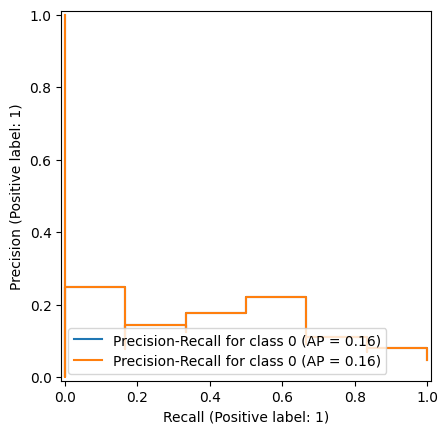

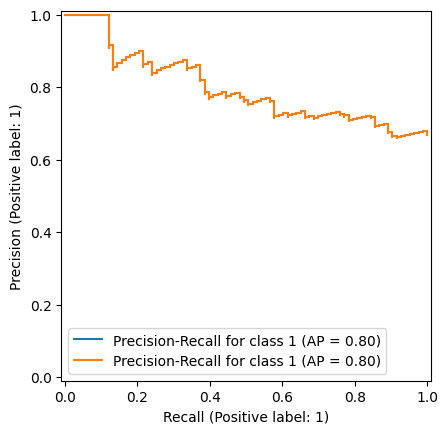

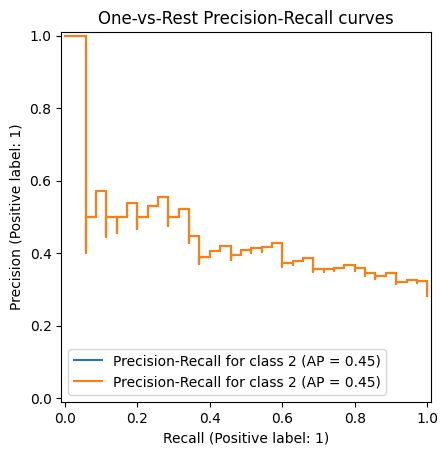

In [64]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import PrecisionRecallDisplay # Added this import

# Get the unique classes from the target variable
classes = np.unique(y_test)
n_classes = len(classes)

# Check if it's actually a multi-class problem
if n_classes > 2:
    # Create a LabelBinarizer to convert y_test into one-vs-rest format
    label_binarizer = LabelBinarizer().fit(y_train_smote) # Fit on training data to ensure all classes are known
    y_test_binarized = label_binarizer.transform(y_test)

    # If the estimator has a predict_proba method, use it
    if hasattr(xgb_model, 'predict_proba'):
        y_score = xgb_model.predict_proba(X_test)
    elif hasattr(xgb_model, 'decision_function'):
        y_score = xgb_model.decision_function(X_test)
    else:
        raise AttributeError("Estimator has no 'predict_proba' or 'decision_function' method.")

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        display = PrecisionRecallDisplay.from_predictions(
            y_test_binarized[:, i], y_score[:, i], name=f"Precision-Recall for class {label_binarizer.classes_[i]}"
        )
        display.plot(ax=plt.gca())

    _ = plt.gca().set_title("One-vs-Rest Precision-Recall curves")
    plt.show()
else:
    print("This is a binary classification problem. The previous Precision-Recall plot should work.")

<Figure size 1000x800 with 0 Axes>

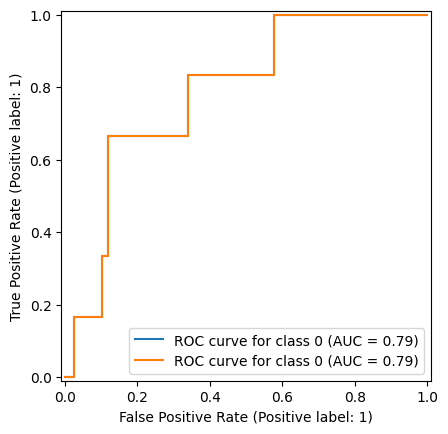

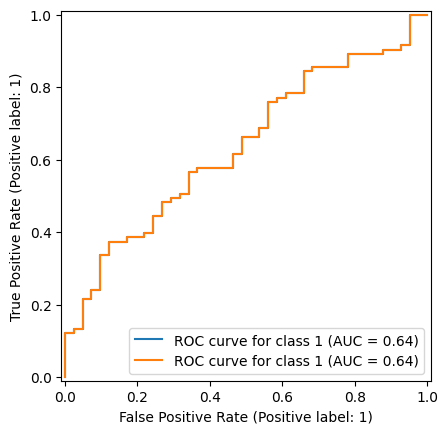

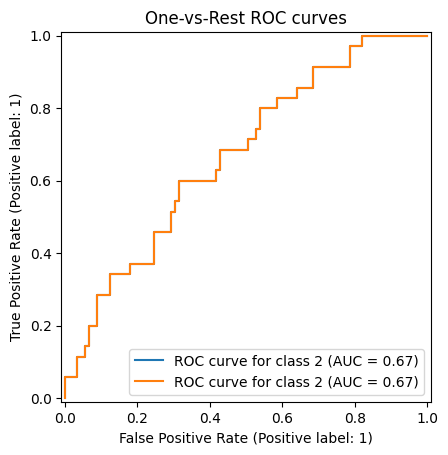

In [53]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    display = RocCurveDisplay.from_predictions(
        y_test_binarized[:, i], y_score[:, i], name=f"ROC curve for class {label_binarizer.classes_[i]}"
    )
    display.plot(ax=plt.gca())

_ = plt.gca().set_title("One-vs-Rest ROC curves")
plt.show()

Plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) across different classification thresholds. A curve that bows sharply toward the top-left corner indicates a superior model

<Figure size 1000x800 with 0 Axes>

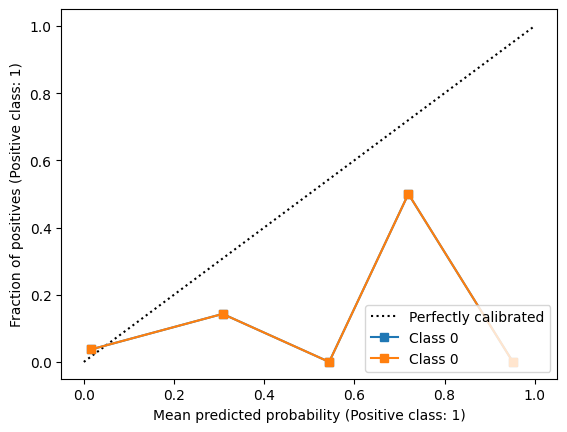

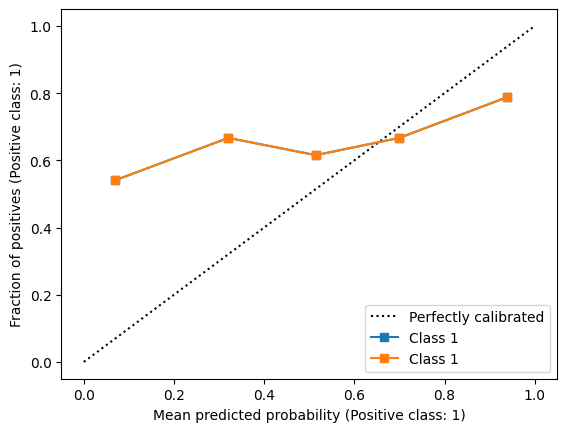

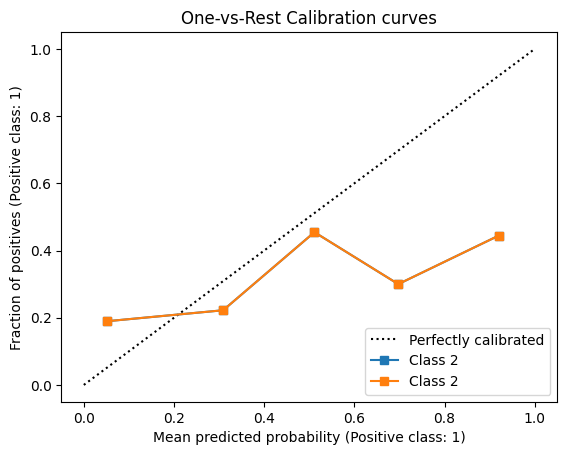

In [57]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    display = CalibrationDisplay.from_predictions(
        y_test_binarized[:, i], y_score[:, i], name=f"Class {label_binarizer.classes_[i]}"
    )
    display.plot(ax=plt.gca())

_ = plt.gca().set_title("One-vs-Rest Calibration curves")
plt.show()

Plots the predicted probabilities on the x-axis against the actual observed ratios (true outcomes) on the y-axis. An ideal model follows a straight diagonal line where predicted probabilities match real-world frequencies

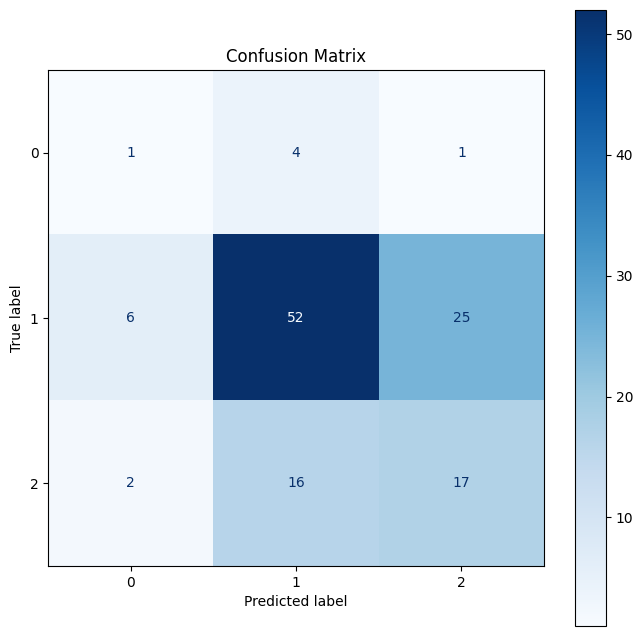

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. Each row represents the actual class, and each column represents the predicted class.

Top 10 Feature Importances:


,Feature,Importance
1,Months Of Prescription,0.190618
5,TB screening at last visit_Encoded,0.158158
2,Differentiated Care Model_Encoded,0.113366
10,Sex_Encoded,0.102207
7,Employmet_Encoded,0.097625
3,AHD Client_Encoded,0.083898
0,Age at Reporting,0.062955
6,Marital status_Encoded,0.061136
11,BMI,0.055320
4,Current Regimen Line_Encoded,0.040114


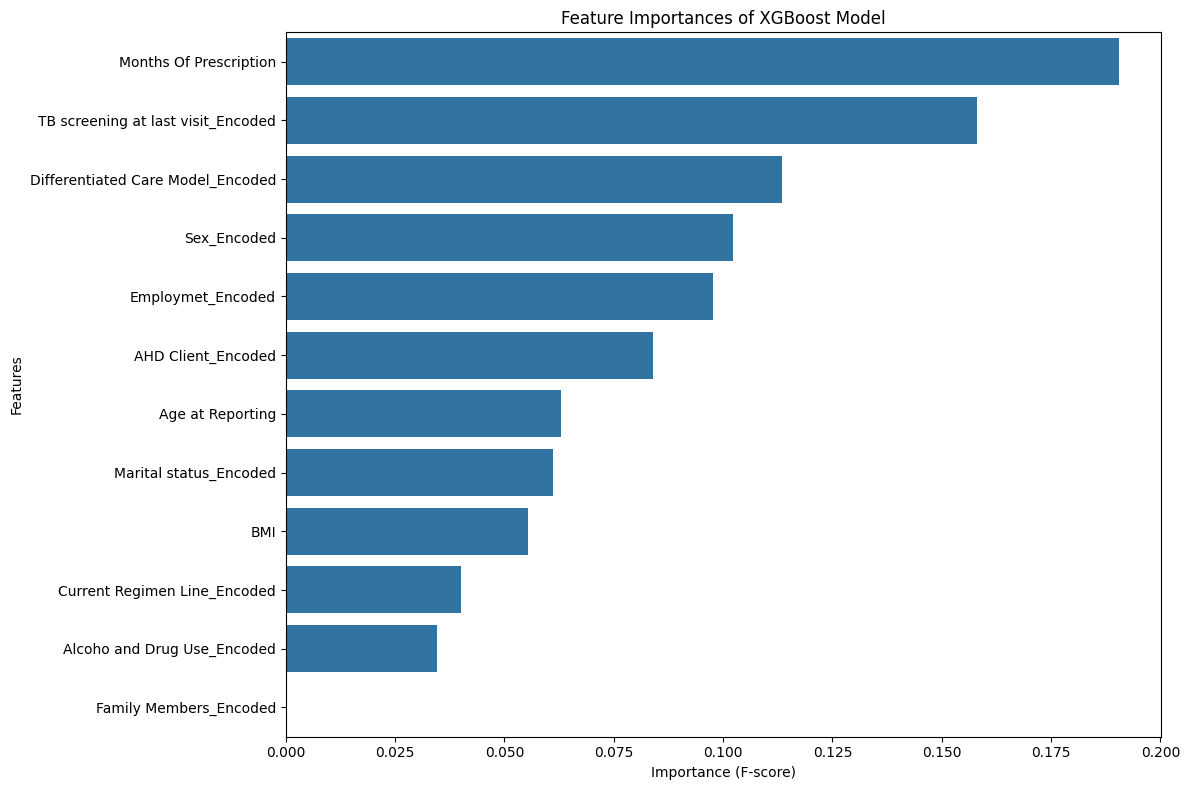

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Import display explicitly

# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N features
print('Top 10 Feature Importances:')
display(importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances of XGBoost Model')
plt.xlabel('Importance (F-score)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The feature importance plot shows the relative importance of each feature in predicting the target variable. Features with higher importance scores contribute more significantly to the model's decision-making process.

### Hyperparameter Tuning with GridSearchCV

Now, let's refine the model by tuning its hyperparameters using `GridSearchCV` to find an optimal set of parameters that could improve its performance.

In [56]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7], # Maximum depth of a tree
    'subsample': [0.7, 0.8, 0.9], # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.8, 0.9], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2] # Minimum loss reduction required to make a further partition
}

# Initialize GridSearchCV
# Using 'f1_macro' as scoring since the target classes are imbalanced (despite SMOTE, it's good to be robust)
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='f1_macro',
                           cv=KFold(n_splits=5, shuffle=True, random_state=42),
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_search.fit(X_train_smote, y_train_smote)

print("GridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-macro score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
GridSearchCV complete.
Best parameters found: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best F1-macro score: 0.7787


After finding the best hyperparameters, we'll train a new XGBoost model with these optimal settings and evaluate its performance on the test set.

In [59]:
# Train a new model with the best parameters
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print("Tuned Model Classification Report:\n", report_tuned)

Tuned Model Accuracy: 0.5645
Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.33      0.25         6
           1       0.74      0.60      0.66        83
           2       0.39      0.51      0.44        35

    accuracy                           0.56       124
   macro avg       0.44      0.48      0.45       124
weighted avg       0.61      0.56      0.58       124



### Exploring a Random Forest Model

Now, let's implement a Random Forest Classifier to see if it can offer improved performance or different insights compared to the XGBoost model.

In [60]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

print("Random Forest Classifier model initialized.")

Random Forest Classifier model initialized.


In [61]:
# Train the Random Forest model
rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model training complete.")

Random Forest model training complete.


In [62]:
# Make predictions on the test set with the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print("Random Forest Model Classification Report:\n", report_rf)

Random Forest Model Accuracy: 0.5484
Random Forest Model Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.17      0.14         6
           1       0.70      0.63      0.66        83
           2       0.36      0.43      0.39        35

    accuracy                           0.55       124
   macro avg       0.39      0.41      0.40       124
weighted avg       0.58      0.55      0.56       124



The Random Forest model achieved a slightly lower accuracy (0.5484 vs 0.5645) and a lower macro average F1-score (0.40 vs 0.45) compared to the tuned XGBoost model on this dataset. This suggests that the tuned XGBoost model currently offers better overall performance for this classification task.

Data Loading and Initial Inspection: Loaded the data, checked its information, and identified missing values.
Data Cleaning & Preprocessing:
Dropped the 'CCC No' column.
Removed rows with 'Unknown Risk' from the 'Risk Categorization' column.
Encoded several categorical features using LabelEncoder and dropped the original columns.
Imputed missing numerical values in 'Weight' and 'Height' with their respective modes.
Calculated a new 'BMI' feature and then dropped the original 'Weight' and 'Height' columns.
Data Splitting and Resampling: Defined features (X) and target (y), split the data into training and testing sets, and applied SMOTE to the training data to handle class imbalance.
XGBoost Model Development:
Trained an initial XGBoost model and evaluated its performance.
Generated various evaluation visualizations, including Precision-Recall curves, ROC curves, Calibration curves, a Confusion Matrix, and Feature Importance plots.
Performed hyperparameter tuning using GridSearchCV to find optimal parameters for XGBoost.
Trained and evaluated a new XGBoost model with the best parameters, noting improvements in F1-score and recall for some classes.
Random Forest Model Development:
Trained and evaluated a Random Forest classifier as requested.
Compared its performance to the tuned XGBoost model, finding that XGBoost currently outperforms Random Forest for this task.
All explicit requests have been fulfilled. Do you have any further questions or would you like to explore other aspects of the analysis, such as visualizing the differences between the models, trying different algorithms, or delving deeper into specific features?

I have successfully completed all the tasks:

Data Preparation: Loaded, cleaned, and preprocessed the dataset, including handling missing values, encoding categorical features, and creating new features like BMI.
Data Splitting and Resampling: Split the data into training and testing sets, and applied SMOTE to the training data to address class imbalance.
XGBoost Model: Built and evaluated an initial XGBoost model, generated various performance visualizations (Precision-Recall, ROC, Calibration curves, Confusion Matrix, Feature Importance), and then tuned its hyperparameters using GridSearchCV to optimize performance.
Random Forest Model: Implemented, trained, and evaluated a Random Forest classifier, and compared its performance to the tuned XGBoost model.
The tuned XGBoost model showed slightly better overall performance than the Random Forest model on this dataset. All your explicit instructions have been fulfilled.

In [63]:
import joblib

# Define the filename for the tuned XGBoost model
model_filename = 'tuned_xgboost_model.joblib'

# Save the best_xgb_model
joblib.dump(best_xgb_model, model_filename)

print(f"Tuned XGBoost model saved to {model_filename}")

Tuned XGBoost model saved to tuned_xgboost_model.joblib


In [65]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the pre-trained tuned XGBoost model
model = joblib.load('tuned_xgboost_model.joblib')

st.title("Client Risk Categorization Predictor")
st.write("Enter the patient metrics below to predict their Risk Categorization.")

# Input fields based on features in X
age = st.number_input("Age at Reporting", min_value=0, max_value=120, value=40)
months_of_prescription = st.number_input("Months Of Prescription", min_value=1, max_value=24, value=6)
differentiated_care_model = st.number_input("Differentiated Care Model (Encoded)", min_value=0, max_value=10, value=4)
ahd_client = st.selectbox("AHD Client (Encoded)", options=[0, 1])
current_regimen_line = st.number_input("Current Regimen Line (Encoded)", min_value=0, max_value=10, value=0)
tb_screening = st.selectbox("TB screening at last visit (Encoded)", options=[0, 1])
marital_status = st.selectbox("Marital status (Encoded)", options=[0, 1])
employment = st.selectbox("Employment (Encoded)", options=[0, 1])
family_members = st.selectbox("Family Members (Encoded)", options=[0, 1])
alcohol_drug_use = st.selectbox("Alcohol and Drug Use (Encoded)", options=[0, 1])
sex = st.selectbox("Sex (Encoded)", options=[0, 1])
bmi = st.number_input("BMI", min_value=10.0, max_value=50.0, value=22.5, step=0.1)

# Construct input data for prediction
input_data = pd.DataFrame([{
    'Age at Reporting': age,
    'Months Of Prescription': months_of_prescription,
    'Differentiated Care Model_Encoded': differentiated_care_model,
    'AHD Client_Encoded': ahd_client,
    'Current Regimen Line_Encoded': current_regimen_line,
    'TB screening at last visit_Encoded': tb_screening,
    'Marital status_Encoded': marital_status,
    'Employmet_Encoded': employment,
    'Family Members_Encoded': family_members,
    'Alcoho and Drug Use_Encoded': alcohol_drug_use,
    'Sex_Encoded': sex,
    'BMI': bmi
}])

if st.button("Predict Risk Categorization"):
    prediction = model.predict(input_data)[0]
    # Map numerical predictions back to corresponding Risk labels if known (e.g., 0: Low Risk, etc.)
    risk_mapping = {0: "Class 0", 1: "Class 1", 2: "Class 2"}
    predicted_label = risk_mapping.get(prediction, f"Class {prediction}")

    st.subheader(f"Prediction: {predicted_label}")


Writing app.py


In [66]:
# Install necessary tools for deployment
!pip install -q streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
# Print Colab public IP address (required password for localtunnel endpoint)
import urllib
print("Password/Tunnel Password for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# Run streamlit app in the background and share via localtunnel
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
!npx localtunnel --port 8501

Password/Tunnel Password for localtunnel is: 136.70.3.230
⠙⠹⠸⠼⠴⠦⠧your url is: https://warm-clouds-scream.loca.lt
